In [1]:
!pip install tensorflow-model-optimization -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 6.5 MB/s eta 0:00:00


In [2]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import tensorflow_model_optimization as tfmot

os.makedirs("models", exist_ok=True)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype("float32").reshape(-1, 784) / 255.0
X_test = X_test.astype("float32").reshape(-1, 784) / 255.0

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
Training data: (60000, 784)
Testing data : (10000, 784)


In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 [==============================] - 3s 4ms/step - loss: 0.3861 - accuracy: 0.8939 - val_loss: 0.1702 - val_accuracy: 0.9563
Epoch 2/5
422/422 [==============================] - 1s 3ms/step - loss: 0.1771 - accuracy: 0.9488 - val_loss: 0.1261 - val_accuracy: 0.9658
Epoch 3/5
422/422 [==============================] - 1s 3ms/step - loss: 0.1297 - accuracy: 0.9629 - val_loss: 0.1048 - val_accuracy: 0.9695
Epoch 4/5
422/422 [==============================] - 1s 3ms/step - loss: 0.1008 - accuracy: 0.9712 - val_loss: 0.0893 - val_accuracy: 0.9743
Epoch 5/5
422/422 [==============================] - 2s 5ms/step - loss: 0.0811 - accuracy: 0.9766 - val_loss: 0.0846 - val_accuracy: 0.9735


In [6]:
model.save("models/baseline_ann.h5")

loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("Baseline model saved!")
print("Baseline accuracy:", round(acc, 4))

/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Baseline model saved!
Baseline accuracy: 0.9735


In [7]:
def get_size(path):
    return os.path.getsize(path) / 1024

def measure_latency(model_fn, data, runs=100):
    start = time.time()

    for _ in range(runs):
        model_fn(data[:1], verbose=0)

    return (time.time() - start) / runs * 1000

baseline_size = get_size("models/baseline_ann.h5")
baseline_loss, baseline_acc = model.evaluate(
    X_test, y_test, verbose=0
)
baseline_latency = measure_latency(model.predict, X_test)

print("Baseline size (KB):", round(baseline_size, 1))
print("Baseline accuracy :", round(baseline_acc, 4))
print("Baseline latency (ms):", round(baseline_latency, 2))

Baseline size (KB): 1217.0
Baseline accuracy : 0.9735
Baseline latency (ms): 74.92


In [8]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

quantized_tflite_model = converter.convert()

with open("models/quantized_model.tflite", "wb") as f:
    f.write(quantized_tflite_model)

quant_size = get_size("models/quantized_model.tflite")

print("Quantized model created!")
print("Quantized size (KB):", round(quant_size, 1))

Quantized model created!
Quantized size (KB): 103.1


In [9]:
interpreter = tf.lite.Interpreter(
    model_path="models/quantized_model.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0

start = time.time()

for i in range(len(X_test)):
    input_data = X_test[i:i+1].astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_data
    )

    interpreter.invoke()

    prediction = interpreter.get_tensor(
        output_details[0]["index"]
    )

    if np.argmax(prediction) == y_test[i]:
        correct += 1

quant_acc = correct / len(X_test)
quant_latency = (time.time() - start) / len(X_test) * 1000

print("Quantized size (KB):", round(quant_size, 1))
print("Quantized accuracy :", round(quant_acc, 4))
print("Quantized latency (ms):", round(quant_latency, 2))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized size (KB): 103.1
Quantized accuracy : 0.9737
Quantized latency (ms): 0.03


In [10]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=1000
    )
}

pruned_model = prune_low_magnitude(
    model,
    **pruning_params
)

pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

In [11]:
pruned_model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2
469/469 [==============================] - 15s 19ms/step - loss: 0.0708 - accuracy: 0.9797
Epoch 2/2
469/469 [==============================] - 2s 4ms/step - loss: 0.0590 - accuracy: 0.9835


In [14]:
final_pruned_model = tfmot.sparsity.keras.strip_pruning(
    pruned_model
)

final_pruned_model.save(
    "models/pruned_model.h5"
)

pruned_size = get_size(
    "models/pruned_model.h5"
)
final_pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
pruned_loss, pruned_acc = final_pruned_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

pruned_latency = measure_latency(
    final_pruned_model.predict,
    X_test
)

print("Pruned model saved!")
print("Pruned size (KB):", round(pruned_size, 1))
print("Pruned accuracy :", round(pruned_acc, 4))
print("Pruned latency (ms):", round(pruned_latency, 2))

/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Pruned model saved!
Pruned size (KB): 412.1
Pruned accuracy : 0.9769
Pruned latency (ms): 120.04



MODEL OPTIMIZATION COMPARISON
Model                    Size (KB)      Accuracy       Latency (ms)
------------------------------------------------------------
Original                 1217.0         0.9735         74.92
Quantized (TFLite)       103.1          0.9737         0.03
Pruned                   412.1          0.9769         120.04


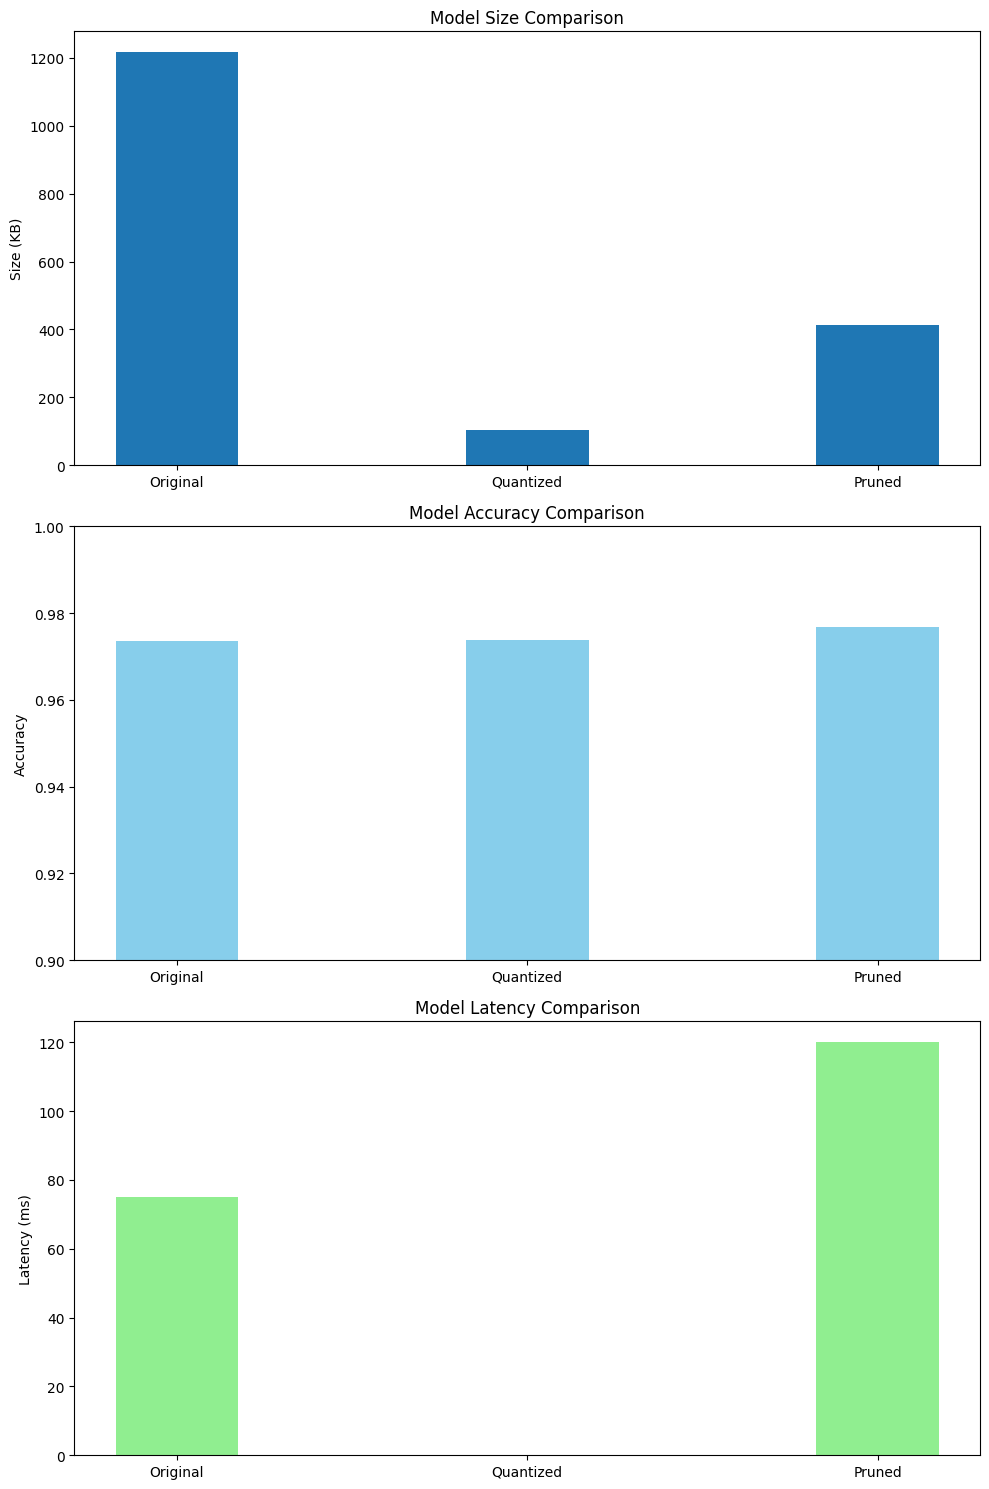

In [17]:
print("\n" + "="*60)
print("MODEL OPTIMIZATION COMPARISON")
print("="*60)

print(f"{'Model':<25}{'Size (KB)':<15}{'Accuracy':<15}{'Latency (ms)'}")
print("-"*60)

print(f"{'Original':<25}{baseline_size:<15.1f}{baseline_acc:<15.4f}{baseline_latency:.2f}")
print(f"{'Quantized (TFLite)':<25}{quant_size:<15.1f}{quant_acc:<15.4f}{quant_latency:.2f}")
print(f"{'Pruned':<25}{pruned_size:<15.1f}{pruned_acc:<15.4f}{pruned_latency:.2f}")

import matplotlib.pyplot as plt

models = ['Original', 'Quantized', 'Pruned']
sizes = [baseline_size, quant_size, pruned_size]
accuracies = [baseline_acc, quant_acc, pruned_acc]
latencies = [baseline_latency, quant_latency, pruned_latency]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Size comparison
ax[0].bar(x, sizes, width)
ax[0].set_ylabel('Size (KB)')
ax[0].set_title('Model Size Comparison')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)

# Accuracy comparison
ax[1].bar(x, accuracies, width, color='skyblue')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Model Accuracy Comparison')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].set_ylim(0.9, 1.0) # Set a reasonable y-limit for accuracy

# Latency comparison
ax[2].bar(x, latencies, width, color='lightgreen')
ax[2].set_ylabel('Latency (ms)')
ax[2].set_title('Model Latency Comparison')
ax[2].set_xticks(x)
ax[2].set_xticklabels(models)

plt.tight_layout()
plt.show()

In [16]:
print("\nFiles generated:")

for file in os.listdir("models"):
    print("✓", file)


Files generated:
✓ pruned_model.h5
✓ baseline_ann.h5
✓ quantized_model.tflite
